# Lista 5 - SVM e Comitês de Modelos

**Disciplina:** CKP8277 - Aprendizagem Automatica | **Periodo:** 2026.1
**Professor:** Cesar Lincoln Cavalcante Mattos
**Aluno:** Diego Melo do Nascimento | **Matricula:** 603127

- **Questao 1a:** Grid-search com 10-fold CV interno + loop externo 10-fold (Nested CV)
- **Questao 1b:** Metricas, curva ROC e curva Precision-Recall — media sobre os folds externos

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from warnings import filterwarnings

filterwarnings('ignore')
np.random.seed(42)

## Carrega os Dados

In [2]:
data = np.genfromtxt('data/californiabin.csv', delimiter=',')
x = data[:, :-1]
y = data[:, -1].astype(int)

print(f'Numero de amostras: {x.shape[0]}')
print(f'Numero de dimensoes: {x.shape[1]}')
print(f'Amostras por classe: {np.unique(y, return_counts=True)}')

Numero de amostras: 2000
Numero de dimensoes: 8
Amostras por classe: (array([0, 1]), array([1000, 1000]))


## Funcoes Auxiliares (implementadas do zero)

In [3]:
def binary_metrics(y_true, y_pred, pos=1):
    tp = np.sum((y_pred == pos) & (y_true == pos))
    fp = np.sum((y_pred == pos) & (y_true != pos))
    fn = np.sum((y_pred != pos) & (y_true == pos))
    tn = np.sum((y_pred != pos) & (y_true != pos))
    acc  = (tp + tn) / len(y_true)
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    return acc, rec, prec, f1

def confusion_matrix_manual(y_true, y_pred, labels):
    cm = np.zeros((len(labels), len(labels)), dtype=int)
    idx_map = {c: i for i, c in enumerate(labels)}
    for t, p in zip(y_true, y_pred):
        cm[idx_map[t], idx_map[p]] += 1
    return cm

def roc_curve_manual(y_true, y_score, pos=1):
    thresholds = np.sort(np.unique(y_score))[::-1]
    P = np.sum(y_true == pos)
    N = np.sum(y_true != pos)
    fprs, tprs = [0.0], [0.0]
    for t in thresholds:
        yp = (y_score >= t).astype(int)
        tp = np.sum((yp == 1) & (y_true == pos))
        fp = np.sum((yp == 1) & (y_true != pos))
        fprs.append(fp / N if N > 0 else 0.0)
        tprs.append(tp / P if P > 0 else 0.0)
    fprs.append(1.0); tprs.append(1.0)
    return np.array(fprs), np.array(tprs)

def pr_curve_manual(y_true, y_score, pos=1):
    thresholds = np.sort(np.unique(y_score))[::-1]
    P = np.sum(y_true == pos)
    precs, recs = [], []
    for t in thresholds:
        yp = (y_score >= t).astype(int)
        tp = np.sum((yp == 1) & (y_true == pos))
        fp = np.sum((yp == 1) & (y_true != pos))
        precs.append(tp / (tp + fp) if (tp + fp) > 0 else 1.0)
        recs.append(tp / P if P > 0 else 0.0)
    precs, recs = np.array(precs), np.array(recs)
    ordem = np.argsort(recs)
    return precs[ordem], recs[ordem]

def auc_manual(xs, ys):
    return float(np.abs(np.trapezoid(ys, xs)))

## Funcoes Principais (estrutura do professor)

In [4]:
def inner_loop(x, y, model_class, grid, internal_kfold=10, scale_flag=True,
               verbose=False, random_state=42):
    """
    Estrutura do professor: np.meshgrid para gerar o grid, KFold interno.
    Retorna os melhores hiperparametros encontrados via CV interno.
    """
    param_names = list(grid.keys())
    grid_search = np.meshgrid(*grid.values())
    grid_search = np.hstack([np.atleast_2d(g.ravel()).T for g in grid_search], dtype='object')

    kf = KFold(n_splits=internal_kfold, shuffle=True, random_state=random_state)

    best_score  = -np.inf
    best_params = {}

    for combo in grid_search:
        params = {k: v for k, v in zip(param_names, combo) if v is not None}

        fold_scores = []
        for tr_idx, va_idx in kf.split(x):
            x_tr_f, x_va_f = x[tr_idx], x[va_idx]
            y_tr_f, y_va_f = y[tr_idx], y[va_idx]

            if scale_flag:
                modelo = make_pipeline(StandardScaler(), model_class(**params))
            else:
                modelo = model_class(**params)

            modelo.fit(x_tr_f, y_tr_f)
            acc, _, _, _ = binary_metrics(y_va_f, modelo.predict(x_va_f))
            fold_scores.append(acc)

        media = np.mean(fold_scores)
        if media > best_score:
            best_score  = media
            best_params = params.copy()

    if verbose:
        print(f'      best_params={best_params}  acc_cv={best_score:.4f}')

    return best_params


def run_nested_cv(x, y, model_class, grid, external_kfold=10, internal_kfold=10,
                  scale_flag=True, random_state=42):
    """
    Validacao cruzada aninhada (Nested CV):
      - Loop externo: `external_kfold` folds para estimar a generalizacao
      - Loop interno: `internal_kfold` folds para selecionar hiperparametros
    Retorna dict com listas de metricas por fold externo.
    """
    metrics = {
        'acc': [], 'rec': [], 'prec': [], 'f1': [],
        'roc_auc': [], 'pr_auc': [],
        'roc_curve': [], 'pr_curve': [],
        'conf_mat': [], 'best_params': [],
    }

    kf_out = KFold(n_splits=external_kfold, shuffle=True, random_state=random_state)

    for fold_idx, (train_idx, test_idx) in enumerate(kf_out.split(x)):
        x_train, x_test = x[train_idx], x[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Loop interno: encontra melhores hiperparametros NO TREINO do fold externo
        best_params = inner_loop(x_train, y_train, model_class, grid,
                                 internal_kfold=internal_kfold,
                                 scale_flag=scale_flag,
                                 verbose=True,
                                 random_state=random_state)

        # Treina modelo com melhores params no treino completo do fold externo
        if scale_flag:
            modelo = make_pipeline(StandardScaler(), model_class(**best_params))
        else:
            modelo = model_class(**best_params)

        modelo.fit(x_train, y_train)

        y_pred  = modelo.predict(x_test)
        y_score = modelo.predict_proba(x_test)[:, 1]

        # Metricas
        acc, rec, prec, f1 = binary_metrics(y_test, y_pred)
        metrics['acc'].append(acc)
        metrics['rec'].append(rec)
        metrics['prec'].append(prec)
        metrics['f1'].append(f1)

        fpr, tpr = roc_curve_manual(y_test, y_score)
        metrics['roc_auc'].append(auc_manual(fpr, tpr))
        metrics['roc_curve'].append((fpr, tpr))

        p_pr, r_pr = pr_curve_manual(y_test, y_score)
        metrics['pr_auc'].append(auc_manual(r_pr, p_pr))
        metrics['pr_curve'].append((p_pr, r_pr))

        metrics['conf_mat'].append(confusion_matrix_manual(y_test, y_pred, [0, 1]))
        metrics['best_params'].append(best_params)

        print(f'  Fold {fold_idx+1:2d}: params={best_params} | ' +
              f'acc={acc:.4f} rec={rec:.4f} prec={prec:.4f} f1={f1:.4f} ' +
              f'auroc={metrics["roc_auc"][-1]:.4f}')

    return metrics

## Questao 1a — Nested CV com Grid-Search

### SVM com Kernel RBF

O SVM de **soft margin** resolve:

$$\min_{\boldsymbol{w}, b} \frac{1}{2}\|\boldsymbol{w}\|^2 + C \sum_{i=1}^{N} \xi_i \quad \text{s.a. } (\boldsymbol{w}^\top \boldsymbol{x}_i + b)y_i \geq 1 - \xi_i,\; \xi_i \geq 0$$

Com o kernel Gaussiano (RBF): $k(\boldsymbol{x}_i, \boldsymbol{x}_j) = \exp(-\gamma\,\|\boldsymbol{x}_i - \boldsymbol{x}_j\|^2)$

Grade: $C \in \{2^{-5}, 2^{-3}, \ldots, 2^{15}\}$, $\gamma \in \{2^{-15}, 2^{-13}, \ldots, 2^{3}\}$

In [5]:
C_values     = np.array([2**i for i in range(-5, 16, 2)], dtype=float)   # 11 valores
gamma_values = np.array([2**i for i in range(-15, 4,  2)], dtype=float)   # 10 valores

grid_svm = {'C': C_values, 'gamma': gamma_values}

print(f'C     ({len(C_values)}): {[f"2^{int(np.log2(c))}" for c in C_values]}')
print(f'gamma ({len(gamma_values)}): {[f"2^{int(np.log2(g))}" for g in gamma_values]}')
print(f'Total combinacoes: {len(C_values)*len(gamma_values)}')
print(f'CV: {10}-fold externo x {10}-fold interno')
print()
print('=== Rodando Nested CV — SVM RBF ===')

metrics_svm = run_nested_cv(
    x, y,
    model_class=lambda **kw: SVC(kernel='rbf', probability=True, random_state=42, **kw),
    grid=grid_svm,
    external_kfold=10,
    internal_kfold=10,
    scale_flag=True,
)

C     (11): ['2^-5', '2^-3', '2^-1', '2^1', '2^3', '2^5', '2^7', '2^9', '2^11', '2^13', '2^15']
gamma (10): ['2^-15', '2^-13', '2^-11', '2^-9', '2^-7', '2^-5', '2^-3', '2^-1', '2^1', '2^3']
Total combinacoes: 110
CV: 10-fold externo x 10-fold interno

=== Rodando Nested CV — SVM RBF ===
      best_params={'C': 8.0, 'gamma': 0.5}  acc_cv=0.8617
  Fold  1: params={'C': 8.0, 'gamma': 0.5} | acc=0.8500 rec=0.8431 prec=0.8600 f1=0.8515 auroc=0.8943
      best_params={'C': 32768.0, 'gamma': 0.001953125}  acc_cv=0.8578
  Fold  2: params={'C': 32768.0, 'gamma': 0.001953125} | acc=0.8350 rec=0.8125 prec=0.8835 f1=0.8465 auroc=0.8982
      best_params={'C': 128.0, 'gamma': 0.03125}  acc_cv=0.8589
  Fold  3: params={'C': 128.0, 'gamma': 0.03125} | acc=0.8400 rec=0.8667 prec=0.8349 f1=0.8505 auroc=0.9185
      best_params={'C': 8.0, 'gamma': 0.5}  acc_cv=0.8583
  Fold  4: params={'C': 8.0, 'gamma': 0.5} | acc=0.8750 rec=0.8542 prec=0.8817 f1=0.8677 auroc=0.9433
      best_params={'C': 128.0, 'gamm

### Random Forest

Grade: `n_estimators` $\in \{10,20,\ldots,200\}$, `max_depth` $\in \{4,6,8,10,\text{None}\}$

In [6]:
n_est_values = np.arange(10, 210, 10)
depth_values = np.array([4, 6, 8, 10, None], dtype=object)

grid_rf = {'n_estimators': n_est_values, 'max_depth': depth_values}

print(f'Grid RF: {len(n_est_values)} x {len(depth_values)} = {len(n_est_values)*len(depth_values)} combinacoes')
print()
print('=== Rodando Nested CV — Random Forest ===')

metrics_rf = run_nested_cv(
    x, y,
    model_class=lambda **kw: RandomForestClassifier(random_state=42, n_jobs=-1, **kw),
    grid=grid_rf,
    external_kfold=10,
    internal_kfold=10,
    scale_flag=False,
)

Grid RF: 20 x 5 = 100 combinacoes

=== Rodando Nested CV — Random Forest ===
      best_params={'n_estimators': 140, 'max_depth': 10}  acc_cv=0.8739
  Fold  1: params={'n_estimators': 140, 'max_depth': 10} | acc=0.8400 rec=0.8529 prec=0.8365 f1=0.8447 auroc=0.9242
      best_params={'n_estimators': 180, 'max_depth': 10}  acc_cv=0.8772
  Fold  2: params={'n_estimators': 180, 'max_depth': 10} | acc=0.8300 rec=0.8125 prec=0.8750 f1=0.8426 auroc=0.9148
      best_params={'n_estimators': 150}  acc_cv=0.8778
  Fold  3: params={'n_estimators': 150} | acc=0.8500 rec=0.8667 prec=0.8505 f1=0.8585 auroc=0.9390
      best_params={'n_estimators': 200}  acc_cv=0.8739
  Fold  4: params={'n_estimators': 200} | acc=0.9000 rec=0.8854 prec=0.9043 f1=0.8947 auroc=0.9576
      best_params={'n_estimators': 150, 'max_depth': 10}  acc_cv=0.8650
  Fold  5: params={'n_estimators': 150, 'max_depth': 10} | acc=0.8950 rec=0.9043 prec=0.8763 f1=0.8901 auroc=0.9445
      best_params={'n_estimators': 200, 'max_depth'

## Questao 1b — Metricas e Curvas (media sobre os folds externos)

In [7]:
def resumo(nome, metrics):
    acc  = np.array(metrics['acc'])
    rec  = np.array(metrics['rec'])
    prec = np.array(metrics['prec'])
    f1   = np.array(metrics['f1'])
    rauc = np.array(metrics['roc_auc'])
    pauc = np.array(metrics['pr_auc'])
    n    = len(acc)
    ci   = lambda v: 1.96 * np.std(v) / np.sqrt(n)

    print(f"=== {nome} — {n} folds externos ===")
    print(f"  Acuracia  : {np.mean(acc):.4f} +/- {ci(acc):.4f}")
    print(f"  Revocacao : {np.mean(rec):.4f} +/- {ci(rec):.4f}")
    print(f"  Precisao  : {np.mean(prec):.4f} +/- {ci(prec):.4f}")
    print(f"  F1-score  : {np.mean(f1):.4f} +/- {ci(f1):.4f}")
    print(f"  AUROC     : {np.mean(rauc):.4f} +/- {ci(rauc):.4f}")
    print(f"  AUPRC     : {np.mean(pauc):.4f} +/- {ci(pauc):.4f}")
    print()

resumo('SVM RBF',      metrics_svm)
resumo('Random Forest', metrics_rf)

=== SVM RBF — 10 folds externos ===
  Acuracia  : 0.8560 +/- 0.0143
  Revocacao : 0.8599 +/- 0.0225
  Precisao  : 0.8537 +/- 0.0172
  F1-score  : 0.8562 +/- 0.0147
  AUROC     : 0.9281 +/- 0.0140
  AUPRC     : 0.9205 +/- 0.0146

=== Random Forest — 10 folds externos ===
  Acuracia  : 0.8680 +/- 0.0161
  Revocacao : 0.8650 +/- 0.0193
  Precisao  : 0.8712 +/- 0.0160
  F1-score  : 0.8678 +/- 0.0146
  AUROC     : 0.9430 +/- 0.0110
  AUPRC     : 0.9122 +/- 0.0265



In [8]:
import pandas as pd

def tabela_row(metrics, n):
    ci = lambda v: 1.96 * np.std(v) / np.sqrt(n)
    row = {}
    for chave, col in [('acc','Accuracy'),('rec','Recall'),('prec','Precision'),('f1','F1-score')]:
        v = np.array(metrics[chave])
        row[col] = f"{np.mean(v):.2%} +/- {ci(v):.2%}"
    for chave, col in [('roc_auc','ROC-AUC'),('pr_auc','PR-AUC')]:
        v = np.array(metrics[chave])
        row[col] = f"{np.mean(v):.4f} +/- {ci(v):.4f}"
    return row

n = 10
table = pd.DataFrame([
    tabela_row(metrics_svm, n),
    tabela_row(metrics_rf,  n),
], index=['SVM RBF', 'Random Forest'])
table

,Accuracy,Recall,Precision,F1-score,ROC-AUC,PR-AUC
SVM RBF,85.60% +/- 1.43%,85.99% +/- 2.25%,85.37% +/- 1.72%,85.62% +/- 1.47%,0.9281 +/- 0.0140,0.9205 +/- 0.0146
Random Forest,86.80% +/- 1.61%,86.50% +/- 1.93%,87.12% +/- 1.60%,86.78% +/- 1.46%,0.9430 +/- 0.0110,0.9122 +/- 0.0265


### Curvas ROC e PR — Media sobre os Folds Externos

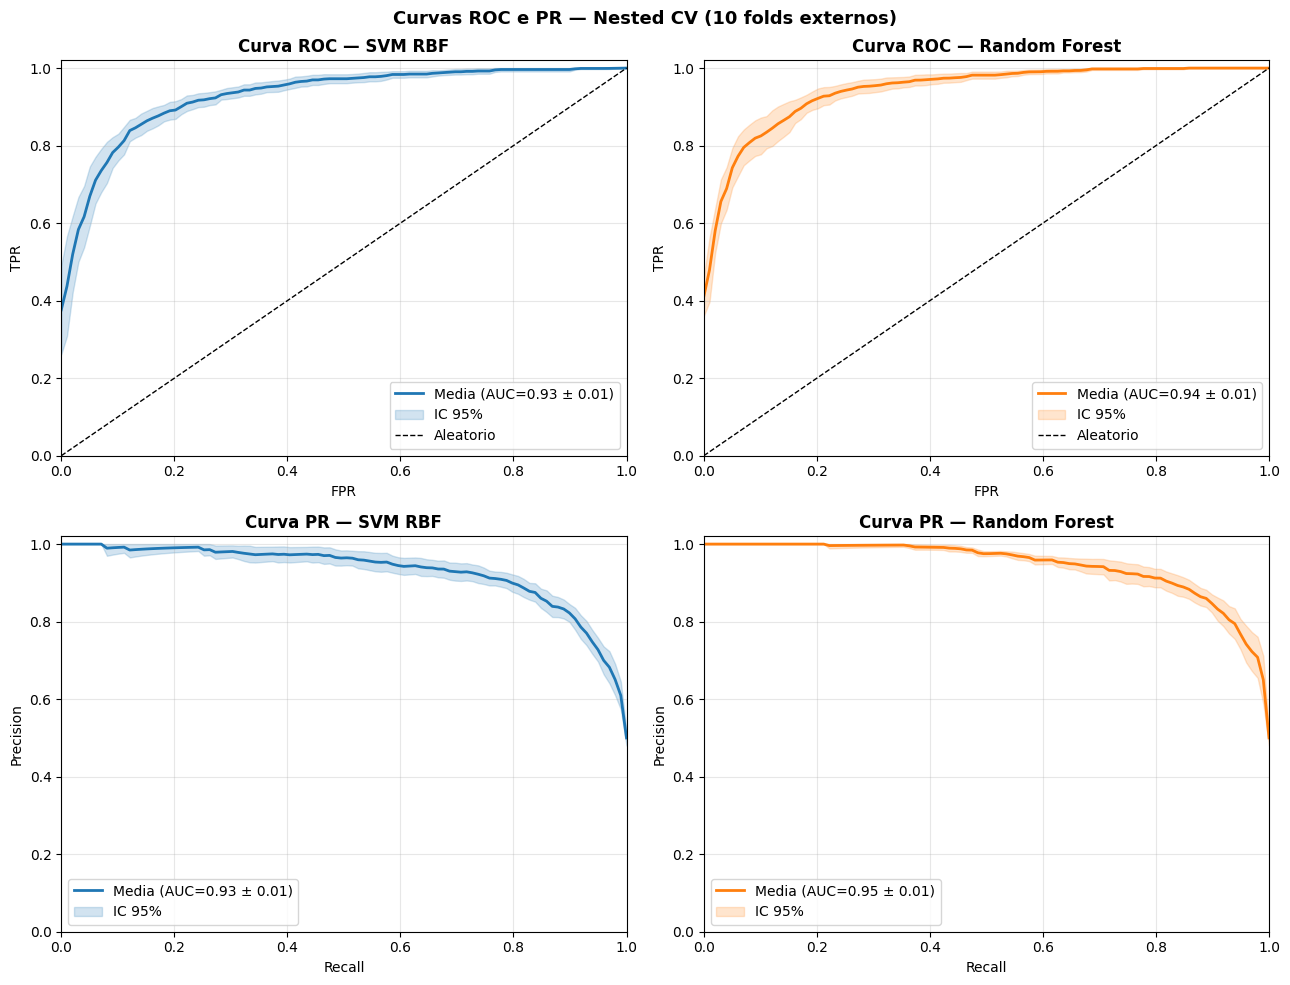

In [9]:
def plot_mean_curves(metrics_svm, metrics_rf):
    mean_fpr = np.linspace(0, 1, 100)
    mean_rec = np.linspace(0, 1, 100)

    fig, axes = plt.subplots(2, 2, figsize=(13, 10))
    fig.suptitle('Curvas ROC e PR — Nested CV (10 folds externos)', fontsize=13, fontweight='bold')

    configs = [(metrics_svm, 'SVM RBF', '#1f77b4'), (metrics_rf, 'Random Forest', '#ff7f0e')]
    labels_all = []

    for col_ax, (metrics, nome, cor) in enumerate(configs):
        # ROC
        tprs = []
        for fpr, tpr in metrics['roc_curve']:
            tprs.append(np.interp(mean_fpr, fpr, tpr))
        mean_tpr = np.mean(tprs, axis=0); mean_tpr[-1] = 1.0
        std_tpr  = np.std(tprs, axis=0) / np.sqrt(len(tprs))
        mean_auc = auc_manual(mean_fpr, mean_tpr)
        std_auc  = np.std(metrics['roc_auc']) / np.sqrt(len(metrics['roc_auc']))

        ax = axes[0, col_ax]
        ax.plot(mean_fpr, mean_tpr, color=cor, lw=2,
                label=f'Media (AUC={mean_auc:.2f} ± {std_auc:.2f})')
        ax.fill_between(mean_fpr,
                        np.maximum(mean_tpr - 1.96*std_tpr, 0),
                        np.minimum(mean_tpr + 1.96*std_tpr, 1),
                        color=cor, alpha=0.2, label='IC 95%')
        ax.plot([0,1],[0,1],'k--',lw=1,label='Aleatorio')
        ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
        ax.set_title(f'Curva ROC — {nome}', fontweight='bold')
        ax.legend(); ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
        ax.grid(True, alpha=0.3)

        # PR
        prcs = []
        for p_pr, r_pr in metrics['pr_curve']:
            prcs.append(np.interp(mean_rec, r_pr, p_pr))
        mean_prc = np.mean(prcs, axis=0)
        std_prc  = np.std(prcs, axis=0) / np.sqrt(len(prcs))
        mean_prauc = auc_manual(mean_rec, mean_prc)
        std_prauc  = np.std(metrics['pr_auc']) / np.sqrt(len(metrics['pr_auc']))

        ax = axes[1, col_ax]
        ax.plot(mean_rec, mean_prc, color=cor, lw=2,
                label=f'Media (AUC={mean_prauc:.2f} ± {std_prauc:.2f})')
        ax.fill_between(mean_rec,
                        np.maximum(mean_prc - 1.96*std_prc, 0),
                        np.minimum(mean_prc + 1.96*std_prc, 1),
                        color=cor, alpha=0.2, label='IC 95%')
        ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
        ax.set_title(f'Curva PR — {nome}', fontweight='bold')
        ax.legend(); ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_mean_curves(metrics_svm, metrics_rf)

### Matriz de Confusao Media

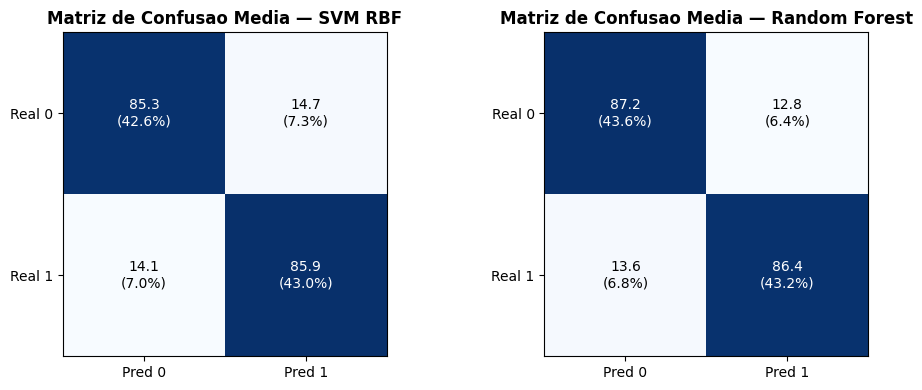

In [10]:
def plot_cm_mean(cm_mean, labels, titulo, ax):
    ax.imshow(cm_mean, cmap='Blues')
    total = cm_mean.sum()
    for i in range(len(labels)):
        for j in range(len(labels)):
            v = cm_mean[i, j]
            ax.text(j, i, f'{v:.1f}\n({v/total*100:.1f}%)',
                    ha='center', va='center', fontsize=10,
                    color='white' if v > cm_mean.max()/2 else 'black')
    ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
    ax.set_xticklabels([f'Pred {l}' for l in labels])
    ax.set_yticklabels([f'Real {l}' for l in labels])
    ax.set_title(titulo, fontweight='bold')

cm_svm_mean = np.mean(metrics_svm['conf_mat'], axis=0)
cm_rf_mean  = np.mean(metrics_rf['conf_mat'],  axis=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_cm_mean(cm_svm_mean, [0,1], 'Matriz de Confusao Media — SVM RBF',       axes[0])
plot_cm_mean(cm_rf_mean,  [0,1], 'Matriz de Confusao Media — Random Forest',  axes[1])
plt.tight_layout()
plt.show()

### Hiperparametros Selecionados por Fold Externo

In [11]:
print("=== SVM — params por fold externo ===")
for i, p in enumerate(metrics_svm['best_params'], 1):
    print(f"  Fold {i:2d}: C=2^{int(np.log2(p['C']))} gamma=2^{int(np.log2(p['gamma']))}")

print()
print("=== Random Forest — params por fold externo ===")
for i, p in enumerate(metrics_rf['best_params'], 1):
    print(f"  Fold {i:2d}: n_estimators={int(p['n_estimators'])}  max_depth={p.get('max_depth',None)}")

=== SVM — params por fold externo ===
  Fold  1: C=2^3 gamma=2^-1
  Fold  2: C=2^15 gamma=2^-9
  Fold  3: C=2^7 gamma=2^-5
  Fold  4: C=2^3 gamma=2^-1
  Fold  5: C=2^7 gamma=2^-5
  Fold  6: C=2^11 gamma=2^-7
  Fold  7: C=2^11 gamma=2^-7
  Fold  8: C=2^3 gamma=2^-1
  Fold  9: C=2^11 gamma=2^-7
  Fold 10: C=2^13 gamma=2^-7

=== Random Forest — params por fold externo ===
  Fold  1: n_estimators=140  max_depth=10
  Fold  2: n_estimators=180  max_depth=10
  Fold  3: n_estimators=150  max_depth=None
  Fold  4: n_estimators=200  max_depth=None
  Fold  5: n_estimators=150  max_depth=10
  Fold  6: n_estimators=200  max_depth=10
  Fold  7: n_estimators=50  max_depth=None
  Fold  8: n_estimators=80  max_depth=None
  Fold  9: n_estimators=180  max_depth=10
  Fold 10: n_estimators=180  max_depth=None
